# Lab 9 — SVM & PCA
**Sounak** | MCA, CHRIST University (2025–27)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

print("Libraries loaded.")

Libraries loaded.


## Part A: SVM
### Task 1: Load & preprocess
I'm using `load_breast_cancer` — the same UCI dataset, 569 samples, 30 features, binary target.

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0 = malignant, 1 = benign

print("Shape:", X.shape)
print("Target classes:", dict(zip(data.target_names, [0, 1])))
print()
print(y.value_counts().rename(index={0: 'malignant', 1: 'benign'}))
print()
print("Missing values:", X.isnull().sum().sum())
X.describe().T.head(8)

Shape: (569, 30)
Target classes: {np.str_('malignant'): 0, np.str_('benign'): 1}

target
benign       357
malignant    212
Name: count, dtype: int64

Missing values: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012


No missing values, and classes aren't badly imbalanced. Scaling all features since SVM is distance-based and the raw scales vary a lot.

In [3]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.describe().T[['mean', 'std']].head(5)

,mean,std
mean radius,-1.373633e-16,1.00088
mean texture,6.868164e-17,1.00088
mean perimeter,-1.248757e-16,1.00088
mean area,-2.185325e-16,1.00088
mean smoothness,-8.366672e-16,1.00088


### Task 2: Train/test split (80:20)
Using `stratify=y` to keep the malignant/benign ratio consistent in both sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)
print()
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (455, 30)
Test shape:  (114, 30)

Train class balance:
 target
1    0.626
0    0.374
Name: proportion, dtype: float64
Test class balance:
 target
1    0.632
0    0.368
Name: proportion, dtype: float64


### Task 3: Linear kernel SVM + tuning
Baseline linear kernel first, then `GridSearchCV` over kernel/C/gamma to find the best combination.

In [5]:
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_baseline = svm_linear.predict(X_test)
print("Baseline linear-kernel SVM accuracy:", round(accuracy_score(y_test, y_pred_baseline), 4))

Baseline linear-kernel SVM accuracy: 0.9737


In [6]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters found:", grid.best_params_)
print("Best cross-validated F1 score:", round(grid.best_score_, 4))

Best parameters found: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validated F1 score: 0.9828


Linear kernel won the grid search — makes sense, since these 30 features are already well-engineered and close to linearly separable.

In [7]:
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test)
print("Tuned model:", best_svm)

Tuned model: SVC(C=0.1, kernel='linear', random_state=42)


### Task 4: Evaluation

In [8]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



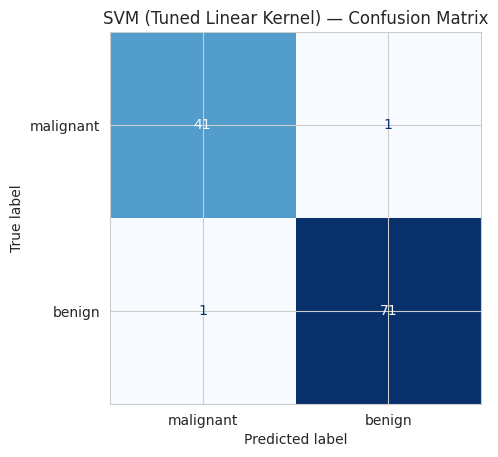

True Negatives (malignant correctly caught): 41
False Positives (malignant missed as benign): 1
False Negatives (benign misclassified as malignant): 1
True Positives (benign correctly identified): 71


In [9]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("SVM (Tuned Linear Kernel) — Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (malignant correctly caught): {tn}")
print(f"False Positives (malignant missed as benign): {fp}")
print(f"False Negatives (benign misclassified as malignant): {fn}")
print(f"True Positives (benign correctly identified): {tp}")

### Observations
98.2% accuracy with precision/recall/F1 all in the mid-to-high 90s. False negatives (malignant missed) are the ones I'd watch closest clinically.

## Part B: PCA
### Task 1: Load & standardize
`load_wine` — 178 samples, 13 features, 3 classes. Standardizing so no single feature dominates the variance by scale alone.

In [10]:
wine = load_wine()
Xw = pd.DataFrame(wine.data, columns=wine.feature_names)
yw = pd.Series(wine.target, name='target')

print("Shape:", Xw.shape)
print("Classes:", dict(zip(wine.target_names, range(3))))
print(yw.value_counts())
print()
print("Feature scale before standardizing (min/max):")
print(Xw.agg(['min', 'max']).T.head(5))

Shape: (178, 13)
Classes: {np.str_('class_0'): 0, np.str_('class_1'): 1, np.str_('class_2'): 2}
target
1    71
0    59
2    48
Name: count, dtype: int64

Feature scale before standardizing (min/max):
                     min     max
alcohol            11.03   14.83
malic_acid          0.74    5.80
ash                 1.36    3.23
alcalinity_of_ash  10.60   30.00
magnesium          70.00  162.00


In [11]:
scaler_w = StandardScaler()
Xw_scaled = scaler_w.fit_transform(Xw)
print("After standardizing, every feature has mean ~0 and std ~1:")
print(pd.DataFrame(Xw_scaled, columns=Xw.columns).agg(['mean', 'std']).T.head(5).round(3))

After standardizing, every feature has mean ~0 and std ~1:
                   mean    std
alcohol            -0.0  1.003
malic_acid         -0.0  1.003
ash                -0.0  1.003
alcalinity_of_ash  -0.0  1.003
magnesium          -0.0  1.003


### Task 2 & 3: PCA (13 → 2) + explained variance

In [12]:
pca_2 = PCA(n_components=2, random_state=42)
Xw_pca2 = pca_2.fit_transform(Xw_scaled)

print("Explained variance ratio per component:")
for i, ratio in enumerate(pca_2.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {ratio:.4f} ({ratio*100:.1f}%)")
print()
print(f"Total variance retained by 2 components: {pca_2.explained_variance_ratio_.sum()*100:.1f}%")

Explained variance ratio per component:
  PC1: 0.3620 (36.2%)
  PC2: 0.1921 (19.2%)

Total variance retained by 2 components: 55.4%


2 components keep just over half the total variance — a strong compression, suggesting the 13 features are fairly correlated.

### Task 4: Cumulative variance for 95%

In [13]:
pca_full = PCA(random_state=42)
pca_full.fit(Xw_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1

print("Cumulative explained variance by component count:")
for i, cv in enumerate(cum_var, start=1):
    marker = "  <- 95% reached here" if i == n_components_95 else ""
    print(f"  {i:2d} components: {cv*100:.2f}%{marker}")

print()
print(f"Minimum components needed for >=95% variance: {n_components_95}")

Cumulative explained variance by component count:
   1 components: 36.20%
   2 components: 55.41%
   3 components: 66.53%
   4 components: 73.60%
   5 components: 80.16%
   6 components: 85.10%
   7 components: 89.34%
   8 components: 92.02%
   9 components: 94.24%
  10 components: 96.17%  <- 95% reached here
  11 components: 97.91%
  12 components: 99.20%
  13 components: 100.00%

Minimum components needed for >=95% variance: 10


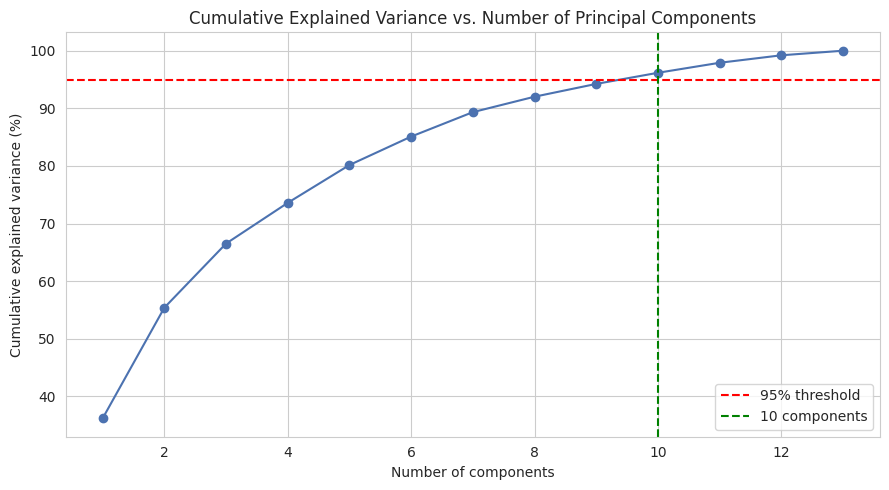

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cum_var)+1), cum_var*100, marker='o', color='#4C72B0')
ax.axhline(95, color='red', linestyle='--', label='95% threshold')
ax.axvline(n_components_95, color='green', linestyle='--', label=f'{n_components_95} components')
ax.set_title("Cumulative Explained Variance vs. Number of Principal Components")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.legend()
plt.tight_layout()
plt.show()

Need **10 components** for 95% variance — the curve flattens fast after the first few, so most signal sits in a handful of directions.

### Task 5: 2D visualization

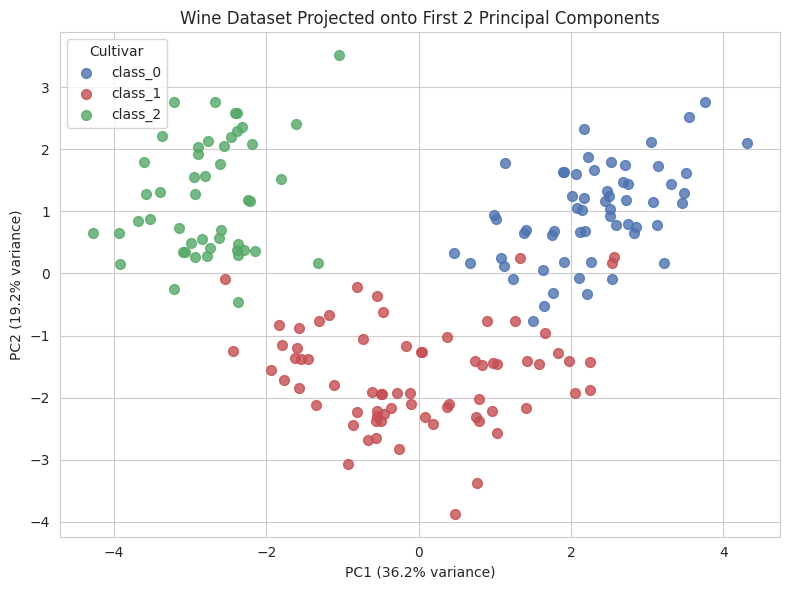

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C72B0', '#C44E52', '#55A868']
for i, target_name in enumerate(wine.target_names):
    mask = yw == i
    ax.scatter(Xw_pca2[mask, 0], Xw_pca2[mask, 1], label=target_name, color=colors[i], s=50, alpha=0.8)

ax.set_title("Wine Dataset Projected onto First 2 Principal Components")
ax.set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(title="Cultivar")
plt.tight_layout()
plt.show()

Even in 2D, the three cultivars form mostly separate clusters — notable since PCA never saw the labels.

### Task 6: Original vs. transformed

In [16]:
comparison = pd.DataFrame({
    'Original (13 features)': [13, '100%', 'Higher — 13-dim distance/model computations'],
    'PCA-transformed (2 components)': [2, f"{pca_2.explained_variance_ratio_.sum()*100:.1f}%",
                                        'Lower — 2-dim, much faster to compute and plot'],
}, index=['Number of features', 'Information retained', 'Computational efficiency'])
comparison

,Original (13 features),PCA-transformed (2 components)
Number of features,13,2
Information retained,100%,55.4%
Computational efficiency,Higher — 13-dim distance/model computations,"Lower — 2-dim, much faster to compute and plot"


13→2 features costs about a third of the variance, but I gain a plottable, faster dataset — a fair trade for visualization, less so if accuracy is the priority.

### Task 7: What do PC1 and PC2 mean?

In [17]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=['PC1', 'PC2'],
    index=wine.feature_names
)
print("Top features driving PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print()
print("Top features driving PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

Top features driving PC1:
flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
proanthocyanins                 0.313429
nonflavanoid_phenols            0.298533
Name: PC1, dtype: float64

Top features driving PC2:
color_intensity    0.529996
alcohol            0.483652
proline            0.364903
ash                0.316069
magnesium          0.299634
Name: PC2, dtype: float64


PC1 tracks phenolic/flavanoid compounds; PC2 tracks color and mineral-related features. Both map to real chemistry, not arbitrary math.

### Task 8: PCA — advantages, limitations, applications
**Advantage:** compresses dimensions without manual feature selection. **Limitation:** components mix all original features, so direct interpretability is lost, and PCA has no idea class labels exist. **Use it for:** visualization, speed, denoising — not when every original feature needs to stay individually interpretable.

## Extra Credit: LDA vs. PCA
Applying LDA to the same data — unlike PCA it uses class labels and optimizes for separating them.

In [18]:
lda = LinearDiscriminantAnalysis(n_components=2)
Xw_lda = lda.fit_transform(Xw_scaled, yw)

print("LDA explained variance ratio per discriminant:")
for i, ratio in enumerate(lda.explained_variance_ratio_, start=1):
    print(f"  LD{i}: {ratio:.4f} ({ratio*100:.1f}%)")

LDA explained variance ratio per discriminant:
  LD1: 0.6875 (68.7%)
  LD2: 0.3125 (31.3%)


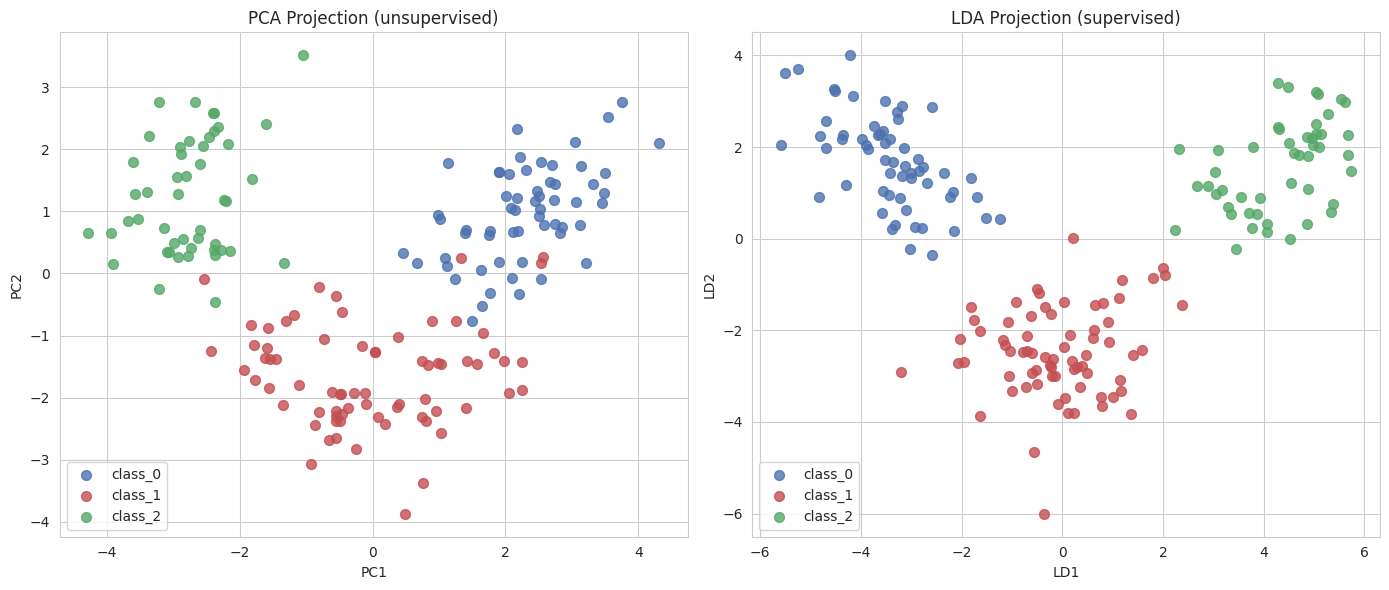

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, target_name in enumerate(wine.target_names):
    mask = yw == i
    axes[0].scatter(Xw_pca2[mask, 0], Xw_pca2[mask, 1], label=target_name, color=colors[i], s=50, alpha=0.8)
axes[0].set_title("PCA Projection (unsupervised)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

for i, target_name in enumerate(wine.target_names):
    mask = yw == i
    axes[1].scatter(Xw_lda[mask, 0], Xw_lda[mask, 1], label=target_name, color=colors[i], s=50, alpha=0.8)
axes[1].set_title("LDA Projection (supervised)")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")
axes[1].legend()

plt.tight_layout()
plt.show()

LDA's clusters are visibly tighter than PCA's, as expected since it's supervised. I'd trust LDA for classification tasks, but PCA is the only option when labels aren't available.